# ANALISI DATA-DRIVEN PER IL SUPPORTO DECISIONALE IN AMBITO ASSICURATIVO

# Scenario

Un'**assicurazione sanitaria** è interessata a sapere come **migliorare il sonno dei propri clienti** tramite la promozione di uno stile di vita sano. L'idea è che in questo modo la compagnia assicurativa sia in grado di migliorare la salute dei propri clienti e, conseguentemente, di ridurre i costi per le cure mediche dei propri assicurati. Per farlo, vuole capire **quali aspetti** dello stile di vita influiscono maggiormente sulla qualità del sonno.

A tal fine, useremo dataset pubblici contenenti dati su attività fisica, qualità del sonno, informazioni demografiche e condizioni di salute di varie persone per analizzarli in relazione all'obiettivo dell'assicurazione sanitaria. Tramite l'utilizzo di Python, realizzeremo quindi un'analisi approfondita che possa consentire all'assicurazione di decidere **quali cambiamenti di comportamento promuovere tra i propri clienti**.

# Raccolta dei dati

Useremo due dataset pubblici, uno artificiale (il primo), che non rappresenta quindi persone reali, pur essendo valido ai fini delle nostre analisi, e uno reale (il secondo):

- https://www.kaggle.com/datasets/hanaksoy/health-and-sleep-statistics
- https://www.kaggle.com/datasets/henryshan/sleep-health-and-lifestyle

Una volta scaricati i due dataset in formato CSV e salvati nella directory di lavoro, andiamoli a caricare in Python usando Pandas.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("Dataset")

df1 = pd.read_csv(DATA_DIR / "Health_Sleep_Statistics.csv")
df2 = pd.read_csv(DATA_DIR / "ss.csv")

Visualizziamo le prime righe in formato tabulare per farci un'idea di come sono strutturati i due dataset.

In [2]:
display(df1.head(n=3))
display(df2.head(n=3))

,User ID,Age,Gender,Sleep Quality,Bedtime,Wake-up Time,Daily Steps,Calories Burned,Physical Activity Level,Dietary Habits,Sleep Disorders,Medication Usage
0,1,25,f,8,23:00,06:30,8000,2500,medium,healthy,no,no
1,2,34,m,7,00:30,07:00,5000,2200,low,unhealthy,yes,yes
2,3,29,f,9,22:45,06:45,9000,2700,high,healthy,no,no


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN


# Elaborazione dei dati

## Trasformazione dei dati

### Qualità del sonno

Visto che il nostro obiettivo è capire quali fattori influenzano di più la qualità del sonno, partiamo proprio da quest'ultima.
Notiamo che la colonna che identifica la qualità del sonno ha due nomi diversi nei due dataset:

- "Sleep Quality" in df1;
- "Quality of Sleep" in df2.

Per semplificare l'analisi, andiamo a rinominare queste colonne in sleep_quality.

In [3]:
df1.rename(columns={"Sleep Quality": "sleep_quality"}, inplace=True)
df2.rename(columns={"Quality of Sleep": "sleep_quality"}, inplace=True)

Controlliamo poi che la distribuzione dei valori di sleep_quality sia simile nei due dataset.

In [4]:
summary = pd.DataFrame({
    "df1": df1["sleep_quality"].describe(),
    "df2": df2["sleep_quality"].describe()
}).loc[["count","mean","std","min","25%","50%","75%","max"]]

display(summary)

,df1,df2
count,100.000000,373.000000
mean,7.000000,7.308311
std,1.734964,1.195359
min,4.000000,4.000000
25%,5.750000,6.000000
50%,7.500000,7.000000
75%,8.250000,8.000000
max,9.000000,9.000000


I due dataset descrivono popolazioni simili (stesso range e livello medio di qualità del sonno). La differenza principale sta nella variabilità:

- df1 mostra una qualità del sonno più eterogenea (alcuni dormono molto bene, altri male);

- df2 mostra più coerenza tra i partecipanti.

La media leggermente più alta di df2 (7.3 vs 7.0) non è enorme, ma su 373 osservazioni potrebbe essere statisticamente significativa.

### Attività fisica

Guardiamo ora **Physical Activity Level**. In un dataset è una variabile categorica, ovvero può assumere solo tre valori: basso, medio e alto. Nell'altro dataset è un numero intero (minuti giornalieri di attività fisica).

In [5]:
display(df1["Physical Activity Level"].value_counts())
print("\n")
display(df2["Physical Activity Level"].describe())

Physical Activity Level
medium    38
high      36
low       26
Name: count, dtype: int64

count    373.000000
mean      59.128686
std       20.842589
min       30.000000
25%       45.000000
50%       60.000000
75%       75.000000
max       90.000000
Name: Physical Activity Level, dtype: float64

Visto che in df2 il livello di attività fisica varia da 30 a 90, decidiamo di creare tre intervalli:

- *low* se < 50
- *medium* se 51–70
- *high* se > 70

In [6]:
df2.loc[df2["Physical Activity Level"] <= 50, "physical_activity"] = "low"
df2.loc[(df2["Physical Activity Level"] > 50) & (df2["Physical Activity Level"] <= 70), "physical_activity"] = "medium"
df2.loc[df2["Physical Activity Level"] > 70, "physical_activity"] = "high"
df2.drop(columns=["Physical Activity Level"], inplace=True)
df1.rename(columns={"Physical Activity Level": "physical_activity"}, inplace=True)

### Indice di massa corporea

Guardiamo ora l'indice di massa corporea, presente solo nel secondo dataset.

In [7]:
display(df2["BMI Category"].value_counts())

BMI Category
Normal           195
Overweight       147
Normal Weight     21
Obese             10
Name: count, dtype: int64

Notiamo che alcuni pazienti sono contrassegnati da "Normal Weight" e altri da "Normal". Questo probabilmente è un errore di trascrittura dei dati. Uniformiamo la categoria.

In [8]:
df2.loc[(df2["BMI Category"] == "Normal") | (df2["BMI Category"] == "Normal Weight"), "BMI Category"] = "Normal"

### Durata del sonno

Vediamo che in df1 vengono forniti gli orari in cui la persona è andata a dormire e si è alzata, mentre in df2 vengono fornite solo le ore totali di sonno. Il dataset df1 ha quindi una maggiore risoluzione rispetto al dataset df2.

Visto che df1 ha più granuralità del secondo, andiamo a calcolare la durata del sonno per df1.

In [9]:
df1["Wake-up Time"] = pd.to_datetime(df1["Wake-up Time"], format="%H:%M")
df1["Bedtime"] = pd.to_datetime(df1["Bedtime"], format="%H:%M")
df1["sleep_duration"] = (df1["Wake-up Time"] - df1["Bedtime"]).dt.seconds / 3600
df1.drop(columns=["Wake-up Time", "Bedtime"], inplace=True)
df2.rename(columns={"Sleep Duration": "sleep_duration"}, inplace=True)

### Pressione del sangue

Notiamo che la pressione del sangue è rappresentata da una stringa con due valori: la pressione sistolica e quella diastolica.

In [10]:
df2["Blood Pressure"].head(n=3)

0    126/83
1    125/80
2    125/80
Name: Blood Pressure, dtype: object

Separiamo la pressione in sistolica e diastolica ed eliminiamo le altre colonne che sono state già utilizzate.

In [11]:
# Separazione pressione in sistolica e diastolica
df2[['systolic_bp', 'diastolic_bp']] = df2["Blood Pressure"].str.split('/', n=2, expand=True).astype(float)

# Eliminazione delle altre colonne che sono state già utilizzate
df2.drop(columns=["Blood Pressure"], inplace=True)

### Disturbi del sonno

Nel dataset df1, i disturbi del sonno sono semplicemente una categoria yes/no. Nel dataset df2, invece, ci sono persone con apnea e insonnia (due tipi diversi di disturbo del sonno) e le persone senza disturbi del sonno hanno NaN in questa colonna. Andiamo a sostituire i NaN con "no" per uniformarli a df1. Manteniamo però la granularità del tipo di disturbo.

In [12]:
df1.rename(columns={"Sleep Disorders": "has_sleep_disorder"}, inplace=True)
df2.rename(columns={"Sleep Disorder": "has_sleep_disorder"}, inplace=True)
df2.loc[df2.has_sleep_disorder.isna(), "has_sleep_disorder"] = "no"

### Dati restanti

In modo simile, andiamo a rinominare anche altre colonne che corrispondono a informazioni simili.

In [13]:
# Rinominiamo le altre colonne
df1.rename(columns={"User ID": "user_id",
                    "Daily Steps": "daily_steps",
                    "Age": "age",
                    "Gender": "gender",
                    "Calories Burned": "calories_burned",
                    "Dietary Habits": "dietary_habits",
                    "Medication Usage": "uses_medication"}, inplace=True)
df2.rename(columns={"Person ID": "user_id", 
                    "Daily Steps": "daily_steps", 
                    "Age": "age", 
                    "Gender": "gender", 
                    "Occupation": "occupation", 
                    "Stress Level": "stress_level", 
                    "BMI Category": "bmi", 
                    "Heart Rate": "heart_rate"}, inplace=True)

# Creazione nuova colonna per dataset
df1["dataset"] = "HSS"
df2["dataset"] = "SHL"

# Concateniamo dataset e user_id
df1["user_id"] = df1["dataset"] + "_" + df1["user_id"].astype(str)
df2["user_id"] = df2["dataset"] + "_" + df2["user_id"].astype(str)
df1.drop(columns=["dataset"], inplace=True)
df2.drop(columns=["dataset"], inplace=True)

# Sostituzione Male con m e Female con f
df1.loc[df1.gender == 'm', 'gender'] = 'Male'
df1.loc[df1.gender == 'f', 'gender'] = 'Female'

### Unione dataset

Siamo ora pronti ad unire i due dataset in uno unico. Da qui in avanti useremo questo dataset aggregato per le analisi.

In [14]:
df = pd.concat([df1, df2]).reset_index(drop=True)
display(df.head(n=3))
display(df.tail(n=3))

,user_id,age,gender,sleep_quality,daily_steps,calories_burned,physical_activity,dietary_habits,has_sleep_disorder,uses_medication,sleep_duration,occupation,stress_level,bmi,heart_rate,systolic_bp,diastolic_bp
0,HSS_1,25,Female,8,8000,2500.0,medium,healthy,no,no,7.5,NaN,NaN,NaN,NaN,NaN,NaN
1,HSS_2,34,Male,7,5000,2200.0,low,unhealthy,yes,yes,6.5,NaN,NaN,NaN,NaN,NaN,NaN
2,HSS_3,29,Female,9,9000,2700.0,high,healthy,no,no,8.0,NaN,NaN,NaN,NaN,NaN,NaN


,user_id,age,gender,sleep_quality,daily_steps,calories_burned,physical_activity,dietary_habits,has_sleep_disorder,uses_medication,sleep_duration,occupation,stress_level,bmi,heart_rate,systolic_bp,diastolic_bp
470,SHL_371,59,Female,9,7000,NaN,high,NaN,Sleep Apnea,NaN,8.0,Nurse,3.0,Overweight,68.0,140.0,95.0
471,SHL_372,59,Female,9,7000,NaN,high,NaN,Sleep Apnea,NaN,8.1,Nurse,3.0,Overweight,68.0,140.0,95.0
472,SHL_373,59,Female,9,7000,NaN,high,NaN,Sleep Apnea,NaN,8.1,Nurse,3.0,Overweight,68.0,140.0,95.0


## Analisi dei dati

### Correlazione tra stile di vita e qualità del sonno

Possiamo usare il nostro dataset risultante dalle elaborazioni precedenti e le librerie grafiche Matplotlib e Seaborn per fare un po' di analisi qualitative tra le variabili che rappresentano lo stile di vita e la variabile sleep_quality.

Se volessimo quantificare queste relazioni dal punto di vista statistico, potremmo calcolare la correlazione di Pearson.

In [15]:
import seaborn as sns
import scipy.stats as ss
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

Per esempio, vediamo che le donne hanno, in media, una qualità del sonno più alta degli uomini.

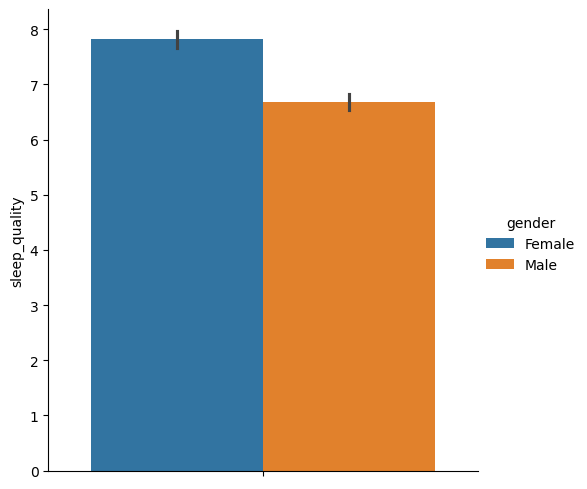

In [16]:
sns.catplot(data=df, kind="bar", y="sleep_quality", hue="gender", hue_order=["Female", "Male"]);

Una dieta salutare porta ad avere una qualità del sonno molto più alta rispetto a una dieta non salutare.

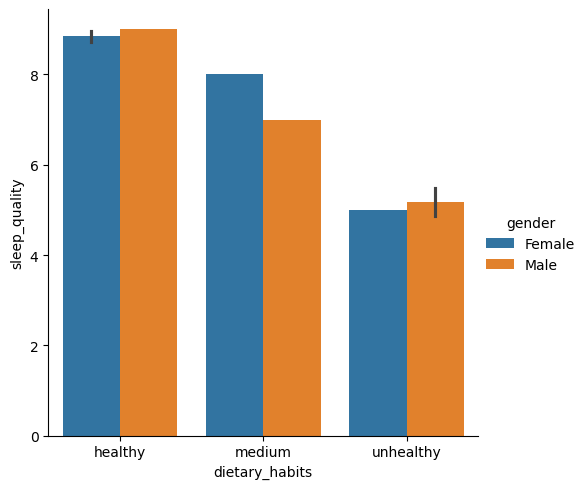

In [17]:
sns.catplot(data=df, kind="bar", x="dietary_habits", y="sleep_quality", hue="gender", order=["healthy", "medium", "unhealthy"] 
            , hue_order=["Female", "Male"]);

Anche l'indice di massa corporea influisce sulla qualità del sonno: le persone in sovrappeso o obese dormono peggio.

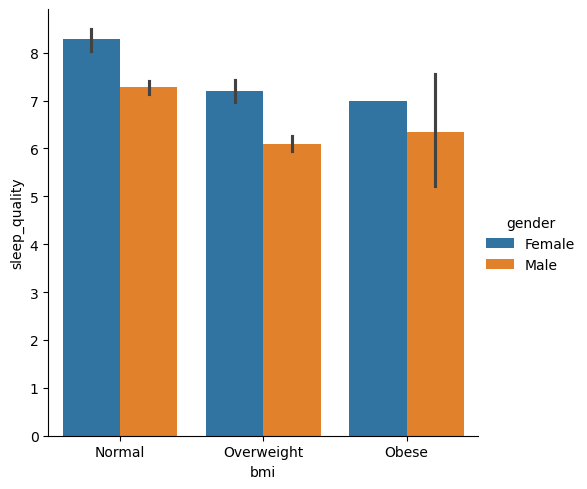

In [18]:
sns.catplot(data=df, kind="bar", x="bmi", y="sleep_quality", hue="gender", order=["Normal", "Overweight", "Obese"] 
            , hue_order=["Female", "Male"]);

Il livello di attività fisica sembra impattare la qualità del sonno solo sui maschi. Ma questa è una metrica qualitativa, quindi dipende molto da come ha interpretato le varie categorie chi l'ha misurata.

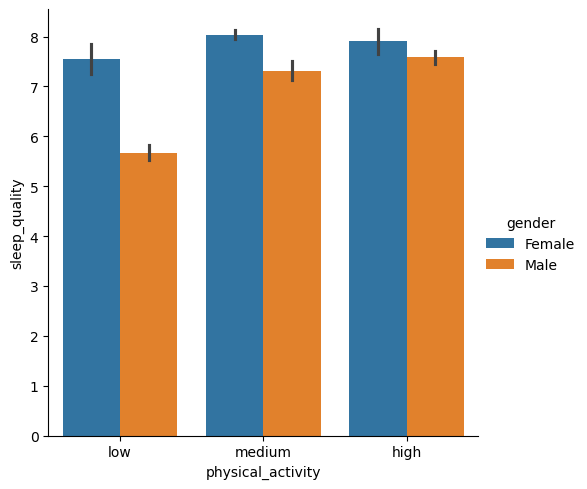

In [19]:
sns.catplot(data=df, kind="bar", x="physical_activity", y="sleep_quality", hue="gender", order=["low", "medium", "high"] 
            , hue_order=["Female", "Male"]);

Se invece guardiamo le calorie consumate, che rispetto al livello di attività fisica possono essere viste un po' come l'altra faccia della stessa medaglia, allora vediamo che c'è una correlazione positiva piuttosto forte con la qualità del sonno.

0.9735569454797837


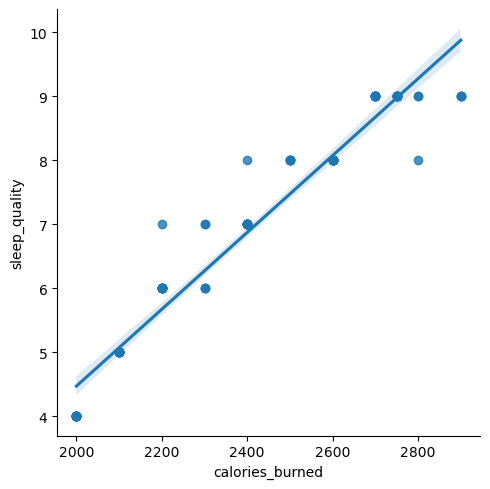

In [20]:
sns.lmplot(data=df, x="calories_burned", y="sleep_quality")
print(df.calories_burned.corr(df.sleep_quality))

Non sorprendetemente, c'è una forte correlazione negativa tra stress e qualità del sonno, ovvero maggiore è lo stress, minore è la qualità del sonno.

-0.8982390052798486


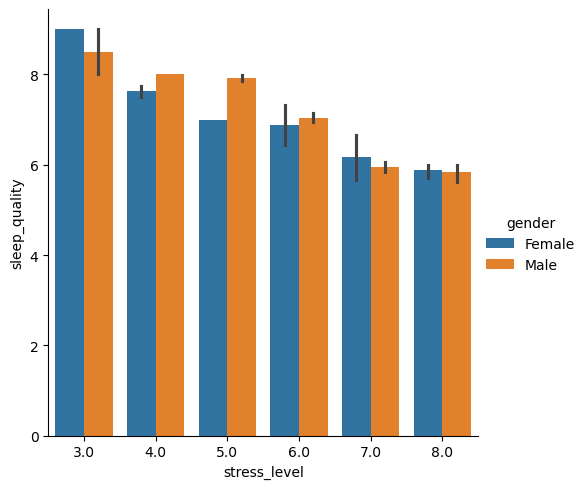

In [21]:
sns.catplot(data=df, kind="bar", x="stress_level", y="sleep_quality", hue="gender", hue_order=["Female", "Male"])
print(df.stress_level.corr(df.sleep_quality))

Per riassumere, avere una **dieta sana**, **consumare tante calorie** e **ridurre lo stress** sembrano essere i tre comportamenti più importanti per migliorare la qualità del sonno.

### Correlazione tra stato di salute e qualità del sonno

In generale, le persone con un disturbo del sonno dormono peggio.

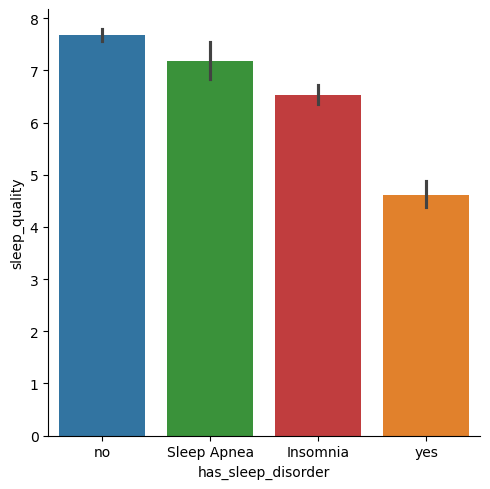

In [22]:
sns.catplot(data=df, kind="bar", y="sleep_quality", x="has_sleep_disorder", hue="has_sleep_disorder"
            , order=["no", "Sleep Apnea", "Insomnia", "yes"]);

Un alto battito cardiaco a riposo è sintomo di un sistema cardiovascolare debole. Queste persone hanno anche una qualità del sonno più bassa.

-0.659887645566984


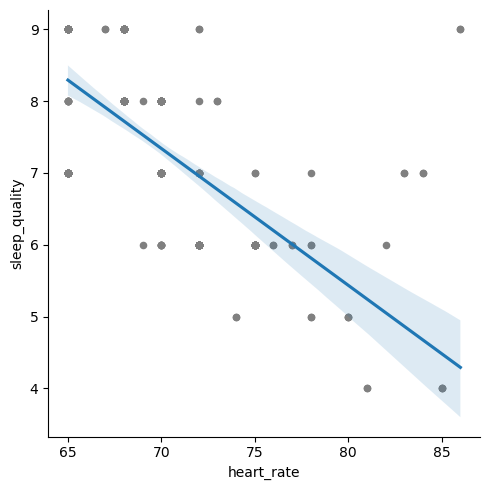

In [23]:
sns.lmplot(data=df, x="heart_rate", y="sleep_quality", scatter_kws={"s": 20, "alpha": 1, "color": "0.5"})
print(df.heart_rate.corr(df.sleep_quality))

La pressione del sangue dovrebbe essere idealmente sotto 120/80 mmHg (sistolica / diastolica). Tuttavia, la qualità del sonno sembra essere solo lievemente peggiore per le persone che ce l'hanno più alta.

-0.12794671756956305
-0.1172738371900214


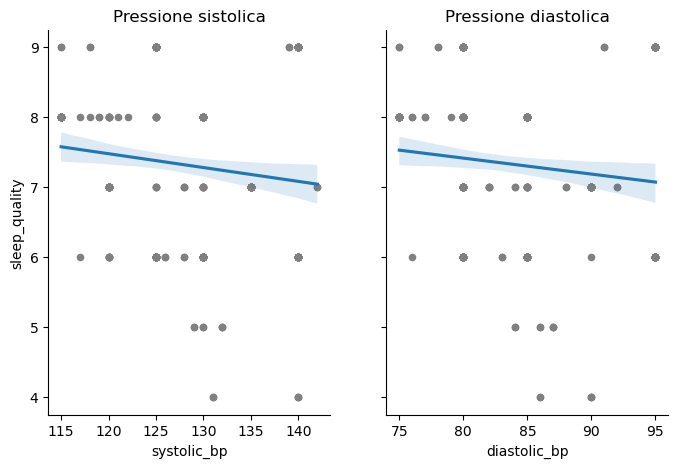

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, figsize=(8, 5))
sns.regplot(data=df, x="systolic_bp", y="sleep_quality", ax=ax1,
            scatter_kws={"s": 20, "alpha": 1, "color": "0.5"})
ax1.set_title("Pressione sistolica")
sns.regplot(data=df, x="diastolic_bp", y="sleep_quality", ax=ax2,
            scatter_kws={"s": 20, "alpha": 1, "color": "0.5"})
ax2.set_title("Pressione diastolica")
ax2.set_ylabel("")
sns.despine()
print(df.systolic_bp.corr(df.sleep_quality))
print(df.diastolic_bp.corr(df.sleep_quality))

# Presentazione dei risultati

## Stratificazione dei clienti

Al fine di presentare i risultati dell'analisi precedente e di fornire le dovute raccomandazioni nel modo più chiaro e semplice possibile, andremo a creare una stratificazione dei clienti tale per cui avremo due gruppi: quello dei clienti sani e quello dei clienti con distrubi del sonno.

### Clienti sani

Definiamo un cliente sano se:

- non ha disturbi del sonno;
- non assume farmaci.

In [25]:
df_sani = df.query("(has_sleep_disorder == 'no') and (uses_medication == 'no')")
df_sani.head()

,user_id,age,gender,sleep_quality,daily_steps,calories_burned,physical_activity,dietary_habits,has_sleep_disorder,uses_medication,sleep_duration,occupation,stress_level,bmi,heart_rate,systolic_bp,diastolic_bp
0,HSS_1,25,Female,8,8000,2500.0,medium,healthy,no,no,7.5,NaN,NaN,NaN,NaN,NaN,NaN
2,HSS_3,29,Female,9,9000,2700.0,high,healthy,no,no,8.0,NaN,NaN,NaN,NaN,NaN,NaN
4,HSS_5,22,Female,8,10000,2800.0,high,medium,no,no,7.5,NaN,NaN,NaN,NaN,NaN,NaN
6,HSS_7,30,Female,8,8500,2600.0,high,healthy,no,no,7.5,NaN,NaN,NaN,NaN,NaN,NaN
8,HSS_9,27,Female,9,9500,2750.0,medium,healthy,no,no,8.5,NaN,NaN,NaN,NaN,NaN,NaN


A questi clienti consigliamo tre cose per migliorare la propria qualità del sonno:

1. Aumentare il numero di calorie consumate giornalmente;

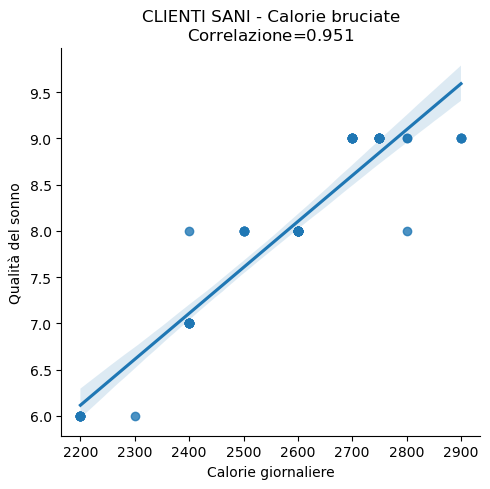

In [26]:
sns.lmplot(data=df_sani, x="calories_burned", y="sleep_quality")
corr = df_sani.calories_burned.corr(df_sani.sleep_quality)
ax = plt.gca()
ax.set_title(f"CLIENTI SANI - Calorie bruciate\nCorrelazione=${corr:.3f}$")
ax.set_xlabel("Calorie giornaliere")
ax.set_ylabel("Qualità del sonno")
plt.tight_layout()
clienti_sani_fig1 = plt.gcf()

2. Migliorare la propria dieta;

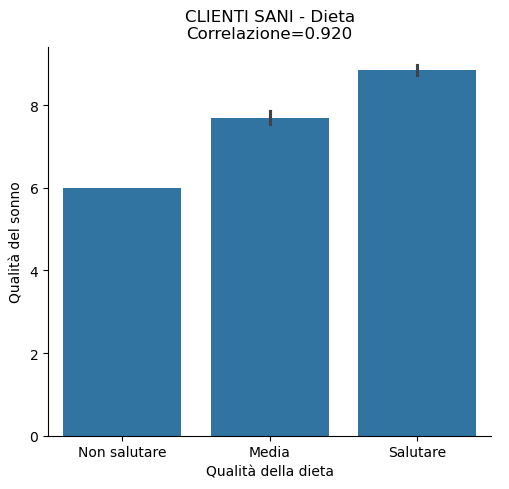

In [27]:
df_sani = df_sani.copy()
sns.catplot(data=df_sani, kind="bar", x="dietary_habits", y="sleep_quality", order=["unhealthy", "medium", "healthy"]) 
df_sani.loc[df_sani.dietary_habits == "unhealthy", "dietary_habits_code"] = 0 
df_sani.loc[df_sani.dietary_habits == "medium", "dietary_habits_code"] = 1 
df_sani.loc[df_sani.dietary_habits == "healthy", "dietary_habits_code"] = 2 
corr = df_sani.dietary_habits_code.corr(df_sani.sleep_quality) 
ax = plt.gca() 
ax.set_title(f"CLIENTI SANI - Dieta\nCorrelazione={corr:.3f}") 
ax.set_xlabel("Qualità della dieta") 
ax.set_ylabel("Qualità del sonno")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Non salutare", "Media", "Salutare"]) 
plt.tight_layout() 
clienti_sani_fig2 = plt.gcf()

3. Dormire più a lungo.

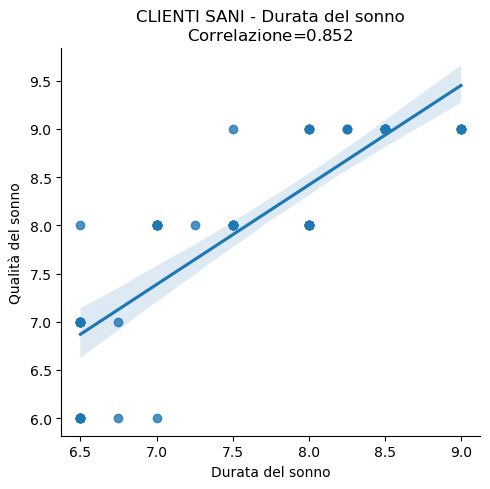

In [28]:
sns.lmplot(data=df_sani, x="sleep_duration", y="sleep_quality")
corr = df_sani.sleep_duration.corr(df_sani.sleep_quality)
ax = plt.gca()
ax.set_title(f"CLIENTI SANI - Durata del sonno\nCorrelazione=${corr:.3f}$")
ax.set_xlabel("Durata del sonno")
ax.set_ylabel("Qualità del sonno")
plt.tight_layout()
clienti_sani_fig3 = plt.gcf()

### Clienti con disturbo del sonno

In [29]:
df_disturbi_sonno = df.query("has_sleep_disorder != 'no'")
df_disturbi_sonno.head()

,user_id,age,gender,sleep_quality,daily_steps,calories_burned,physical_activity,dietary_habits,has_sleep_disorder,uses_medication,sleep_duration,occupation,stress_level,bmi,heart_rate,systolic_bp,diastolic_bp
1,HSS_2,34,Male,7,5000,2200.0,low,unhealthy,yes,yes,6.5,NaN,NaN,NaN,NaN,NaN,NaN
3,HSS_4,41,Male,5,4000,2100.0,low,unhealthy,yes,no,5.5,NaN,NaN,NaN,NaN,NaN,NaN
7,HSS_8,45,Male,4,3000,2000.0,low,unhealthy,yes,yes,5.5,NaN,NaN,NaN,NaN,NaN,NaN
10,HSS_11,50,Female,5,3500,2100.0,low,unhealthy,yes,yes,6.0,NaN,NaN,NaN,NaN,NaN,NaN
13,HSS_14,48,Male,4,3000,2000.0,low,unhealthy,yes,yes,4.5,NaN,NaN,NaN,NaN,NaN,NaN


A questi clienti, dato che logicamente non è possibile chiedergli di eliminare la causa del disturbo del sonno (apnea notturna, insonnia, ecc.), poiché non sono fattori su cui possono incidere direttamente, almeno nel breve periodo, consigliamo allora due cose per migliorare la propria qualità del sonno:

1. Diminuire lo stress;

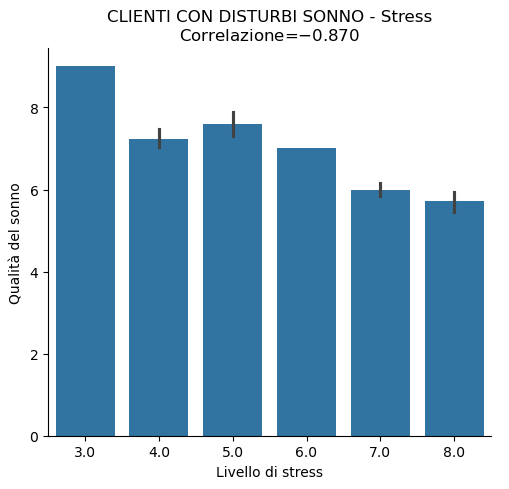

In [30]:
sns.catplot(data=df_disturbi_sonno, kind="bar", x="stress_level", y="sleep_quality")
corr = df_disturbi_sonno.stress_level.corr(df_disturbi_sonno.sleep_quality)
ax = plt.gca()
ax.set_title(f"CLIENTI CON DISTURBI SONNO - Stress\nCorrelazione=${corr:.3f}$")
ax.set_xlabel("Livello di stress")
ax.set_ylabel("Qualità del sonno")
plt.tight_layout()
disturbi_sonno_fig1 = plt.gcf()

2. Fare più attività fisica.

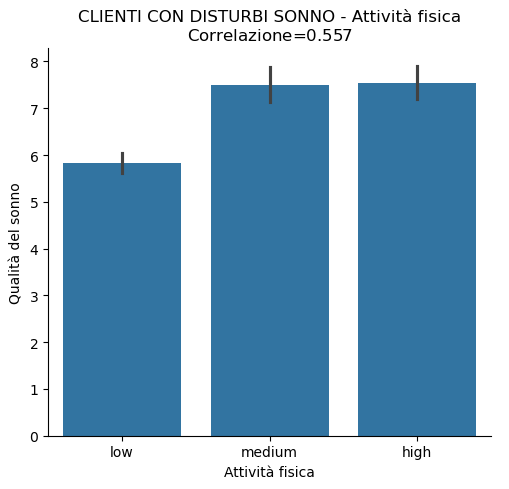

In [31]:
df_disturbi_sonno = df_disturbi_sonno.copy()

sns.catplot(data=df_disturbi_sonno, kind="bar", x="physical_activity", y="sleep_quality",
            order=["low", "medium", "high"])

df_disturbi_sonno.loc[df_disturbi_sonno.physical_activity == "low", "physical_activity_code"] = 0
df_disturbi_sonno.loc[df_disturbi_sonno.physical_activity == "medium", "physical_activity_code"] = 1
df_disturbi_sonno.loc[df_disturbi_sonno.physical_activity == "high", "physical_activity_code"] = 2

corr = df_disturbi_sonno.physical_activity_code.corr(df_disturbi_sonno.sleep_quality)

ax = plt.gca()
ax.set_title(f"CLIENTI CON DISTURBI SONNO - Attività fisica\nCorrelazione=${corr:.3f}$")
ax.set_xlabel("Attività fisica")
ax.set_ylabel("Qualità del sonno")

plt.tight_layout()
disturbi_sonno_fig2 = plt.gcf()

## Creazione e salvataggio report PDF

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import textwrap
from datetime import datetime

# ======================================================
# HEADER / FOOTER
# ======================================================
def add_header_footer(fig, title_left, page_num, total_pages, client="Customers - Sleep Analytics"):
    fig.text(0.06, 0.965, title_left, ha="left", va="top", fontsize=10, weight="bold")
    fig.text(0.94, 0.965, client, ha="right", va="top", fontsize=9)

    fig.lines.append(plt.Line2D([0.06, 0.94], [0.945, 0.945],
                               transform=fig.transFigure, linewidth=1))

    fig.text(0.06, 0.03, "Confidential | Internal use only", ha="left", va="bottom", fontsize=8)
    fig.text(0.94, 0.03, f"{page_num} of {total_pages}", ha="right", va="bottom", fontsize=8)

    fig.lines.append(plt.Line2D([0.06, 0.94], [0.055, 0.055],
                               transform=fig.transFigure, linewidth=1))

# ======================================================
# BOX RECOMMENDATION
# ======================================================
def add_callout_box(fig, title, body, x=0.62, y=0.16, w=0.32, h=0.30):
    ax_box = fig.add_axes([x, y, w, h])
    ax_box.set_xlim(0, 1)
    ax_box.set_ylim(0, 1)
    ax_box.axis("off")

    rect = plt.Rectangle((0, 0), 1, 1, fill=False, linewidth=1)
    ax_box.add_patch(rect)

    ax_box.text(0.05, 0.90, title, fontsize=10, weight="bold", va="top", ha="left")

    wrapped_body = textwrap.fill(body, width=42)
    lines = wrapped_body.count("\n") + 1
    body_font = 9 if lines <= 6 else 8

    ax_box.text(0.05, 0.78, wrapped_body, fontsize=body_font,
                va="top", ha="left", linespacing=1.25)

# ======================================================
# COVER
# ======================================================
def make_cover(pdf, report_title, subtitle, date_str):
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis("off")

    title_wrapped = "\n".join(textwrap.wrap(report_title, width=40))
    title_font = 26 if len(title_wrapped.split("\n")) == 1 else 22

    fig.text(0.06, 0.86, title_wrapped, ha="left", va="top",
             fontsize=title_font, weight="bold", linespacing=1.05)

    subtitle_wrapped = "\n".join(textwrap.wrap(subtitle, width=65))
    fig.text(0.06, 0.75, subtitle_wrapped, ha="left", va="top",
             fontsize=14, linespacing=1.25)

    fig.lines.append(plt.Line2D([0.06, 0.94], [0.67, 0.67],
                               transform=fig.transFigure, linewidth=2))

    fig.text(0.06, 0.61, f"Date: {date_str}", ha="left", va="top", fontsize=10)
    fig.text(0.06, 0.57, "Prepared by: Data Team", ha="left", va="top", fontsize=10)

    pdf.savefig(fig)
    plt.close(fig)

# ======================================================
# EXEC SUMMARY
# ======================================================
def make_exec_summary(pdf, total_pages, page_num, bullets,
                      title_left="Sleep Quality | Executive Summary",
                      client="Customers - Sleep Analytics"):
    fig = plt.figure(figsize=(11.69, 8.27))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis("off")

    add_header_footer(fig, title_left=title_left, page_num=page_num,
                      total_pages=total_pages, client=client)

    fig.text(0.06, 0.90, "Executive summary", ha="left", va="top",
             fontsize=18, weight="bold")
    fig.text(0.06, 0.86, "Key takeaways (so-what)", ha="left", va="top",
             fontsize=11, weight="bold")

    y = 0.80
    for b in bullets:
        wrapped = textwrap.fill(b, width=95)
        fig.text(0.08, y, f"• {wrapped}", ha="left", va="top",
                 fontsize=11, linespacing=1.35)
        y -= 0.10

    pdf.savefig(fig)
    plt.close(fig)

# ======================================================
# CONVERSIONE FIGURA -> ARRAY (e rimozione footer del grafico originale)
# ======================================================
def figure_to_rgba_array(fig_chart, hide_footer_text=True):
    # Nasconde eventuali testi extra aggiunti al grafico originale
    # (es. "Report Qualità del Sonno | Pagina X")
    if hide_footer_text:
        for t in list(fig_chart.texts):
            s = (t.get_text() or "").strip().lower()
            if "report" in s or "pagina" in s:
                t.set_visible(False)

    canvas = FigureCanvas(fig_chart)  # backend Agg robusto
    canvas.draw()
    w, h = canvas.get_width_height()
    buf = np.frombuffer(canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
    return buf

# ======================================================
# PAGINA GRAFICO (slide 3-7)
# ======================================================
def save_chart_page(pdf, fig_chart, total_pages, page_num,
                    insight_title, subtitle,
                    callout_title, callout_body):

    fig = plt.figure(figsize=(11.69, 8.27))

    # Titolo: wrapping per evitare taglio (slide 6-7)
    wrapped_title = "\n".join(textwrap.wrap(insight_title, width=78))
    title_lines = wrapped_title.count("\n") + 1
    title_font = 16 if title_lines == 1 else 14

    fig.text(0.06, 0.92, wrapped_title, ha="left", va="top",
             fontsize=title_font, weight="bold", linespacing=1.05)

    fig.text(0.06, 0.875, subtitle, ha="left", va="top", fontsize=10)

    add_header_footer(fig, title_left="Sleep Quality | Analysis",
                      page_num=page_num, total_pages=total_pages)

    # Area grafico a sinistra
    ax_target = fig.add_axes([0.06, 0.12, 0.52, 0.72])
    ax_target.axis("off")

    img = figure_to_rgba_array(fig_chart, hide_footer_text=True)
    ax_target.imshow(img)
    ax_target.set_aspect("auto")
    ax_target.axis("off")

    # Box
    add_callout_box(fig, callout_title, callout_body, x=0.62, y=0.16, w=0.32, h=0.30)

    pdf.savefig(fig)
    plt.close(fig)

# ======================================================
# GENERAZIONE REPORT (7 pagine)
# ======================================================
date_str = "31 March 2025"
TOTAL_PAGES = 7

exec_bullets = [
    "For healthy customers, sleep quality increases significantly with more physical activity, a better diet, and more hours of rest.",
    "For customers with sleep disorders, stress reduction is the primary driver of improved sleep quality.",
    "Physical activity is an enabling factor in both groups, but with a stronger impact on healthy customers than on those with disorders."
]

output_pdf = "Report_Capstone_Project.pdf"

with PdfPages(output_pdf) as pdf:
    # 1) Cover
    make_cover(
        pdf,
        report_title="Sleep Quality Improvement | Insights & Recommendations",
        subtitle="Behavioral levers for healthy customers vs. customers with sleep disorders",
        date_str=date_str
    )

    # 2) Executive Summary
    make_exec_summary(pdf, total_pages=TOTAL_PAGES, page_num=2, bullets=exec_bullets)

    # 3-7) Grafici
    save_chart_page(
        pdf, clienti_sani_fig1, TOTAL_PAGES, 3,
        insight_title="Increase daily activity to lift sleep quality in healthy customers",
        subtitle="Healthy customers | Relationship between calories burned and sleep quality",
        callout_title="Recommendation",
        callout_body="Introduce a weekly activity goal program (progressive targets) and nudge adherence via reminders; track sleep quality uplift after 4 weeks."
    )

    save_chart_page(
        pdf, clienti_sani_fig2, TOTAL_PAGES, 4,
        insight_title="Diet quality is a strong lever for better sleep among healthy customers",
        subtitle="Healthy customers | Diet quality vs. sleep quality",
        callout_title="Recommendation",
        callout_body="Deploy a nutrition coaching module (simple swaps + meal planning). Prioritize customers with low diet scores for highest ROI."
    )

    save_chart_page(
        pdf, clienti_sani_fig3, TOTAL_PAGES, 5,
        insight_title="More sleep duration correlates with higher sleep quality in healthy customers",
        subtitle="Healthy customers | Sleep duration vs. sleep quality",
        callout_title="Recommendation",
        callout_body="Promote consistent bedtime routines and screen-time reduction; set a target range for sleep duration and monitor compliance."
    )

    save_chart_page(
        pdf, disturbi_sonno_fig1, TOTAL_PAGES, 6,
        insight_title="Stress reduction is the primary driver for improving sleep quality in customers with disorders",
        subtitle="Customers with sleep disorders | Stress level vs. sleep quality",
        callout_title="Recommendation",
        callout_body="Prioritize stress-management interventions (breathing, CBT-I pathway, mindfulness). Segment by stress level to tailor intensity."
    )

    save_chart_page(
        pdf, disturbi_sonno_fig2, TOTAL_PAGES, 7,
        insight_title="Physical activity remains beneficial but with moderate impact for customers with disorders",
        subtitle="Customers with sleep disorders | Physical activity vs. sleep quality",
        callout_title="Recommendation",
        callout_body="Pair light-to-moderate activity plans with stress reduction to amplify effect; avoid over-prescribing intensity initially."
    )

print(f"Creato: {output_pdf}")

Creato: Report_Capstone_Project.pdf
